In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/AI_Student_Life_Pakistan_2026.csv")

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          100 non-null    int64  
 1   Age                 100 non-null    int64  
 2   Gender              100 non-null    str    
 3   Education_Level     100 non-null    str    
 4   City                100 non-null    str    
 5   AI_Tool_Used        100 non-null    str    
 6   Daily_Usage_Hours   100 non-null    float64
 7   Purpose             100 non-null    str    
 8   Impact_on_Grades    100 non-null    str    
 9   Satisfaction_Level  100 non-null    str    
dtypes: float64(1), int64(2), str(7)
memory usage: 12.7 KB


In [3]:
df.describe()

,Student_ID,Age,Daily_Usage_Hours
count,100.000000,100.000000,100.000000
mean,50.500000,19.380000,3.064000
std,29.011492,3.296095,1.564862
min,1.000000,15.000000,0.500000
25%,25.750000,16.000000,1.800000
50%,50.500000,19.000000,3.200000
75%,75.250000,22.000000,4.300000
max,100.000000,25.000000,5.900000


In [4]:
#Investigacion
# # Crea una tabla de frecuencias normalizada
impacto = pd.crosstab(df['AI_Tool_Used'], df['Impact_on_Grades'],normalize=True) *100
# Para encontrar el máximo en una columna específica:
impacto


Impact_on_Grades,Improved,No Change,Slight Decline
AI_Tool_Used,,,
ChatGPT,13.0,4.0,3.0
Copilot,5.0,8.0,4.0
Gemini,8.0,11.0,5.0
Grammarly,6.0,7.0,11.0
Notion AI,7.0,4.0,4.0


In [5]:
#Al investigar lo de crosstab, se me ocurrio que tal vez podia llegar a lo mismo con el groupby.
#Despues de intentar, mira jajaja

impact = df.groupby("AI_Tool_Used")["Impact_on_Grades"].value_counts(normalize=True).unstack() * 100
impact

Impact_on_Grades,Improved,No Change,Slight Decline
AI_Tool_Used,,,
ChatGPT,65.000000,20.000000,15.000000
Copilot,29.411765,47.058824,23.529412
Gemini,33.333333,45.833333,20.833333
Grammarly,25.000000,29.166667,45.833333
Notion AI,46.666667,26.666667,26.666667


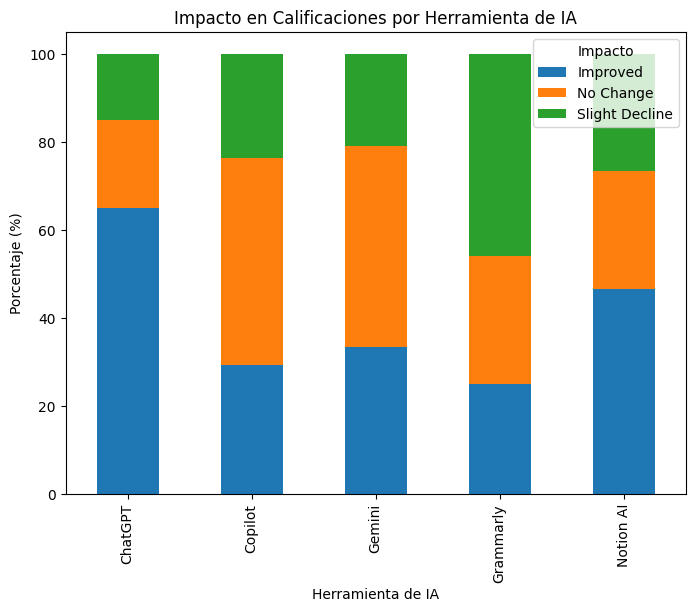

In [6]:
# 'stacked=True' es la magia aquí
impact.plot(kind='bar', stacked=True, figsize=(8, 6))

plt.title('Impacto en Calificaciones por Herramienta de IA')
plt.xlabel('Herramienta de IA')
plt.ylabel('Porcentaje (%)')

# Mover la leyenda afuera para que no tape las barras
plt.legend(title='Impacto')

plt.show()

In [7]:
#1. ¿Cuál herramienta de IA tiene el mayor porcentaje de estudiantes con notas mejoradas? ¿Y cuál es la herramienta de IA que tiene el mayor porcentaje con notas en declive?

print(impact["Improved"].idxmax())
print(impact["Slight Decline"].idxmax())

ChatGPT
Grammarly


In [8]:
grupo_coding_writing = df[ (df["Purpose"] == "Coding") | (df['Purpose']== "Writing")]

comparacion_uso_impato=grupo_coding_writing.groupby("Purpose")["Impact_on_Grades"].value_counts(normalize=True).unstack() *100
comparacion_uso_impato

Impact_on_Grades,Improved,No Change,Slight Decline
Purpose,,,
Coding,55.000000,25.000000,20.000000
Writing,21.428571,57.142857,21.428571


<Axes: xlabel='Purpose'>

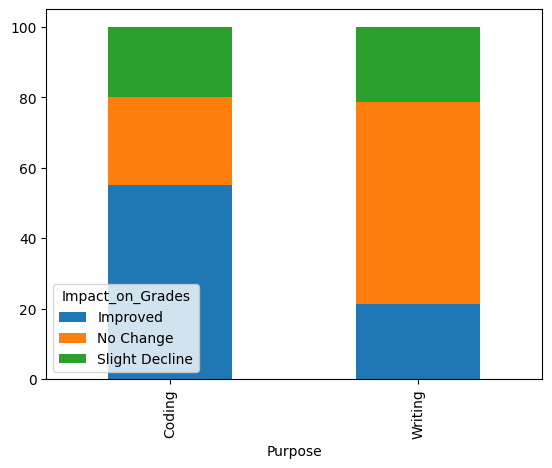

In [9]:
comparacion_uso_impato.plot(kind="bar", stacked=True)

In [10]:
satisfaccion_alta = df[(df["Satisfaction_Level"] == "High") & (df["Impact_on_Grades"] == "Slight Decline")]
satisfaccion_alta.shape

(8, 10)

In [11]:
satisfaccion_alta["AI_Tool_Used"].value_counts()

AI_Tool_Used
Grammarly    3
Notion AI    3
ChatGPT      1
Copilot      1
Name: count, dtype: int64

In [12]:
impacto_cuidades = df.groupby("City")["Impact_on_Grades"].value_counts(normalize=True).unstack() * 100
print(impacto_cuidades["Improved"].idxmax())
print(impacto_cuidades["Improved"].idxmin())

impacto_cuidades["Improved"].sort_values(ascending=False)


Multan
Karachi


City
Multan        51.724138
Lahore        45.454545
Islamabad     33.333333
Faisalabad    29.411765
Karachi       21.428571
Name: Improved, dtype: float64

<Axes: xlabel='City'>

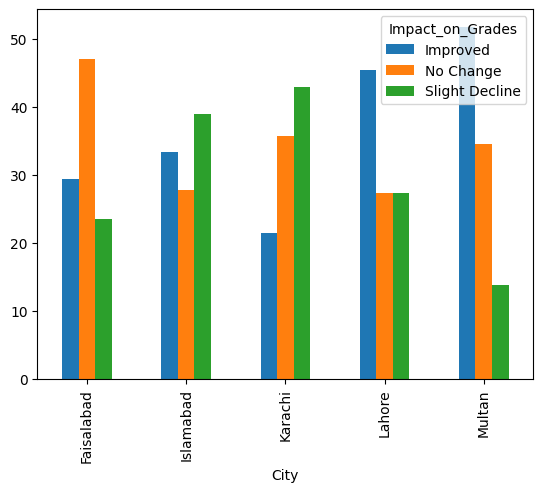

In [13]:
impacto_cuidades.plot(kind="bar")

In [14]:

#6. ¿Cuál es el propósito de uso más común por cada herramienta? ¿Hay alguna herramienta que se esté usando para algo que no parece ser su función principal?"""

uso_IAS = df.groupby("AI_Tool_Used")["Purpose"].value_counts().unstack()
uso_IAS.idxmax(axis=1)

AI_Tool_Used
ChatGPT      Homework
Copilot      Homework
Gemini       Research
Grammarly    Learning
Notion AI    Learning
dtype: str